<a href="https://colab.research.google.com/github/IshanShivanshBangroo/IshanSB_SelectiveGen_SQuAD-2.0/blob/main/IshanSBselective_generation_demo.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Selective generation. Answer, ask or decline

IST 597-002 technical tutorial · Ishan Shivansh Bangroo

This is a replay of one saved Qwen2.5-1.5B-Instruct run: 400 SQuAD 2.0 development questions, six workshop questions and 12 constructed ambiguous questions. The 400-question sample has 200 answerable and 200 unanswerable items; each calibration/test half contains 100 of each.

**Run all uses the saved cache on a CPU. It does not load an LLM or download an embedding model.** The original generation code is preserved at the end, disabled by default. The cache is embedded and hash checked, so the notebook also runs when opened alone in Colab.

These are small-model demonstration results, not official SQuAD accuracy or an evaluation of a deployed answer/ask/decline system. Correctness below means **token F1 ≥ 0.5** against a gold answer, a deliberately relaxed criterion. Exact-match sensitivity is reported separately.


In [1]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
K_SAMPLES = 10
TEMPERATURE = 1.0
MAX_NEW_TOKENS = 24
SEED = 597
TARGET_COVERAGE = 0.5
F1_CORRECT = 0.5
RUN_GENERATION = False
RUN_EMBEDDINGS = False
BOOTSTRAP_RESAMPLES = 2000
ANALYSIS_CACHE_PATH = "results_cache.jsonl"
GENERATION_CACHE_PATH = "results_cache_new.jsonl"
CACHE_PATH = ANALYSIS_CACHE_PATH


## Load and verify the saved run

The JSONL contains one metadata row plus 418 unique question records, ten samples per question, and ten samples per clarified reading. The recorded run used float16 on a Tesla T4; that is provenance in the saved metadata, not a claim that this replay uses a GPU. The exact raw cache is retained unchanged.


In [2]:
from pathlib import Path

import argparse, ast, base64, collections, csv, gzip, hashlib, json, math, re, string

import numpy as np

from sklearn.metrics import roc_auc_score

SEED = 597

SIGNALS = {"Token probability": "tokprob", "Verbalized confidence": "verbal",
           "Sample agreement": "agree", "Lexical cluster entropy": "neg_entropy",
           "Context-sufficiency self-check": "support"}

NO_ANSWER_RE = re.compile(
    r"\bunanswerable\b|\bnot (?:mentioned|stated|specified|provided|given|included|present|found|available|known|clear)\b"
    r"|\b(?:does|do|did)\s*n[o']t (?:say|mention|specify|state|provide|contain|include|indicate|give|tell)\b"
    r"|\bno (?:information|answer|mention|data)\b|\bcan(?:not|'t| not) be (?:determined|answered|found)\b"
    r"|^\s*(?:unknown|none|n/?a)\s*\.?\s*$", re.I)

def sha(raw): return hashlib.sha256(raw).hexdigest()

def normalize_answer(s):
    s = ''.join(c for c in s.lower() if c not in string.punctuation)
    return ' '.join(re.sub(r'\b(a|an|the)\b', ' ', s).split())

def token_f1(a, b):
    a, b = normalize_answer(a).split(), normalize_answer(b).split()
    if not a or not b: return float(a == b)
    common = sum((collections.Counter(a) & collections.Counter(b)).values())
    return 2*common/(len(a)+len(b))

def best_f1(a, golds): return max((token_f1(a,g) for g in golds), default=0.)

def exact_match(a, golds): return any(normalize_answer(a)==normalize_answer(g) for g in golds)

def is_no_answer(s): return bool(NO_ANSWER_RE.search(s or ''))

def canon_tokens(s):
    return [(x.lstrip('0') or '0') if x.isdigit() else x for x in normalize_answer(s).split()]

def same_answer(a, b, mode):
    if mode == 'public_f1': return token_f1(a,b)>=.5
    ta,tb = canon_tokens(a),canon_tokens(b)
    if not ta or not tb: return ta==tb
    common=sum((collections.Counter(ta)&collections.Counter(tb)).values())
    numbers=lambda ts:{x for x in ts if any(c.isdigit() for c in x)}
    return 2*common/(len(ta)+len(tb))>=.5 and numbers(ta)==numbers(tb)

def clusters(texts, mode):
    reps,labels=[],[]
    for t in texts:
        key='<declined>' if is_no_answer(t) else t
        for i,rep in enumerate(reps):
            if key==rep=='<declined>' or ('<declined>' not in (key,rep) and same_answer(key,rep,mode)):
                labels.append(i);break
        else: reps.append(key);labels.append(len(reps)-1)
    return labels,reps

def entropy(counts):
    x=np.asarray(counts,float);x=x[x>0]/x.sum()
    return max(0.,float(-(x*np.log2(x)).sum()))

def sample_entropy(samples,mode): return entropy(list(collections.Counter(clusters(samples,mode)[0]).values()))

def item_row(r,mode):
    f=r['forced'];imp=bool(r['is_impossible']);eligible=not is_no_answer(f)
    wrong=imp or best_f1(f,r['golds'])<.5
    ntok=r.get('forced_ntok') or 0
    return dict(set=r['set'],id=r['id'],split=r.get('split'),answerable=not imp,
                eligible=eligible,wrong=wrong,correct=eligible and not wrong,
                wrong_em=imp or not exact_match(f,r['golds']),
                tokprob=math.exp(r['forced_lp_sum']/ntok) if ntok else np.nan,
                verbal=r['verbal'] if r['verbal'] is not None else np.nan,
                agree=float(np.mean([same_answer(s,f,mode) for s in r['samples']])),
                neg_entropy=-sample_entropy(r['samples'],mode),support=r['support_p_yes'],
                abst_released=not is_no_answer(r['abstain']),
                abst_wrong=imp or best_f1(r['abstain'],r['golds'])<.5,
                abst_wrong_em=imp or not exact_match(r['abstain'],r['golds']),
                abst_correct_em=(not is_no_answer(r['abstain'])) and not(imp or not exact_match(r['abstain'],r['golds'])),
                abst_correct=(not is_no_answer(r['abstain'])) and not(imp or best_f1(r['abstain'],r['golds'])<.5))

def arrays(rows):
    return {k:np.asarray([x[k] for x in rows]) for k in rows[0]}

def sorted_groups(scores,eligible):
    s=np.nan_to_num(np.asarray(scores,float),nan=-np.inf)
    idx=np.flatnonzero(eligible);idx=idx[np.argsort(-s[idx],kind='stable')]
    cuts=np.r_[0,np.flatnonzero(np.diff(s[idx])!=0)+1,len(idx)]
    return [idx[cuts[i]:cuts[i+1]] for i in range(len(cuts)-1)]

def expected_release(scores,eligible,k):
    rel=np.zeros(len(eligible));taken=0
    for g in sorted_groups(scores,eligible):
        if taken>=k:break
        take=min(len(g),k-taken);rel[g]=take/len(g);taken+=take
    return rel

def metrics(rel,wrong,answerable,correct):
    rel=np.asarray(rel,float);n=len(rel);released=rel.sum();errors=float((rel*wrong).sum())
    return dict(n_total=n,expected_released=float(released),expected_errors=errors,
                coverage=float(released/n),risk=errors/released if released else np.nan,
                answerable_declined=float(1-(rel*answerable).sum()/answerable.sum()),
                forced_correct_withheld=float(1-(rel*correct).sum()/correct.sum()) if correct.sum() else np.nan)

def policies(a):
    n=len(a['wrong']);elig=a['eligible'];k=round(.5*n)
    out={'Forced-answer prompt':metrics(elig,a['wrong'],a['answerable'],a['correct'])}
    for name,col in SIGNALS.items():out[name+' gate']=metrics(expected_release(a[col],elig,k),a['wrong'],a['answerable'],a['correct'])
    out["Prompt allows unanswerable"]=metrics(a['abst_released'],a['abst_wrong'],a['answerable'],a['correct'])
    out['Answerability oracle (diagnostic only)']=metrics(elig&a['answerable'],a['wrong'],a['answerable'],a['correct'])
    out['Random eligible gate (expected 50%)']=metrics(elig.astype(float)*min(1.,k/elig.sum()),a['wrong'],a['answerable'],a['correct'])
    return out

def bootstrap(a,n_boot=2000):
    rng=np.random.default_rng(SEED);draws=collections.defaultdict(list)
    for _ in range(n_boot):
        ids=rng.integers(0,len(a['wrong']),len(a['wrong']))
        for name,m in policies({k:v[ids] for k,v in a.items()}).items():draws[name].append(m['risk'])
    return {k:np.asarray(v) for k,v in draws.items()}

def threshold(scores,eligible,n_total,target=.5):
    s=np.sort(np.nan_to_num(np.asarray(scores,float),nan=-np.inf)[eligible])[::-1];k=round(target*n_total)
    if not len(s) or not k:return np.inf,0.
    tau=s[min(k,len(s))-1];gt=int((s>tau).sum());eq=int((s==tau).sum())
    return float(tau),(min(k,len(s))-gt)/eq

def apply_threshold(scores,eligible,tau,q):
    s=np.nan_to_num(np.asarray(scores,float),nan=-np.inf)
    return np.where(s>tau,1.,np.where(s==tau,q,0.))*eligible

def rc_curve(scores,eligible,wrong,n_total):
    cov=[];risk=[];taken=0;wsum=0.
    for g in sorted_groups(scores,eligible):
        for t in range(1,len(g)+1):
            cov.append((taken+t)/n_total);risk.append((wsum+t*wrong[g].sum()/len(g))/(taken+t))
        taken+=len(g);wsum+=wrong[g].sum()
    return np.asarray(cov),np.asarray(risk)

def subset(a,mask): return {k:v[mask] for k,v in a.items()}

def reading_of(text,readings):
    hits=[r['label'] for r in readings if any(f' {normalize_answer(g)} ' in f' {normalize_answer(text)} ' for g in r['golds'] if normalize_answer(g))]
    return 'declined' if is_no_answer(text) else ('both' if len(hits)==2 else hits[0] if hits else 'neither')

def audit_mode(recs,mode,n_boot):
    rs=[r for r in recs if r['set']=='squad'];rows=[item_row(r,mode) for r in rs];a=arrays(rows)
    point=policies(a);boot=bootstrap(a,n_boot)
    for name,m in point.items():m['risk_ci_question_bootstrap']=np.nanpercentile(boot[name],[2.5,97.5]).tolist()
    gates=[name+' gate' for name in SIGNALS];pairs=[]
    for i,g in enumerate(gates):
        for h in ['Forced-answer prompt','Random eligible gate (expected 50%)']+gates[i+1:]:
            pairs.append(dict(a=g,b=h,risk_difference=point[g]['risk']-point[h]['risk'],
                              ci=np.nanpercentile(boot[g]-boot[h],[2.5,97.5]).tolist()))
    cal=subset(a,a['split']=='calib');tst=subset(a,a['split']=='test');held={};rng=np.random.default_rng(SEED)
    held_boot_ids=rng.integers(0,len(tst['wrong']),(n_boot,len(tst['wrong'])))
    for name,col in SIGNALS.items():
        tau,q=threshold(cal[col],cal['eligible'],len(cal['wrong']));rel=apply_threshold(tst[col],tst['eligible'],tau,q)
        m=metrics(rel,tst['wrong'],tst['answerable'],tst['correct']);draw=[]
        for ids in held_boot_ids:draw.append(metrics(rel[ids],tst['wrong'][ids],tst['answerable'][ids],tst['correct'][ids])['risk'])
        held[name]=dict(threshold=tau,tie_release_probability=q,calibration=metrics(apply_threshold(cal[col],cal['eligible'],tau,q),cal['wrong'],cal['answerable'],cal['correct']),test=m,
                        test_risk_ci_conditional_on_calibrated_threshold=np.nanpercentile(draw,[2.5,97.5]).tolist())
    qualities={}
    for name,col in SIGNALS.items():
        cov,risk=rc_curve(a[col],a['eligible'],a['wrong'],len(a['wrong']));mask=a['eligible']&np.isfinite(a[col]);y=~a['wrong'][mask]
        qualities[name]=dict(aurc_full=float(risk.mean()),aurc_from_5_percent=float(risk[cov>=.05].mean()),
                             max_coverage=float(cov[-1]),auroc=float(roc_auc_score(y,a[col][mask])))
    vmask=a['eligible']&np.isfinite(a['verbal']);scores=a['verbal'][vmask];correct=a['correct'][vmask];band=np.clip(np.digitize(scores,np.linspace(0,1,11))-1,0,9)
    bins=[]
    for b in range(10):
        m=band==b
        if m.any():bins.append(dict(bin=b,count=int(m.sum()),mean_confidence=float(scores[m].mean()),accuracy=float(correct[m].mean())))
    ece=sum(x['count']/len(scores)*abs(x['mean_confidence']-x['accuracy']) for x in bins)
    amb=[]
    for r in (r for r in recs if r['set']=='ambig'):
        row=item_row(r,mode);sa,sb=[x['samples'] for x in r['readings']];labs,_=clusters(sa+sb,mode);la,lb=labs[:len(sa)],labs[len(sa):]
        total=entropy(list(collections.Counter(labs).values()));within=.5*entropy(list(collections.Counter(la).values()))+.5*entropy(list(collections.Counter(lb).values()))
        x=dict(id=r['id'],question=r['question'],forced=r['forced'],reading_picked=reading_of(r['forced'],r['readings']),
               original_entropy=sample_entropy(r['samples'],mode),pooled_total=total,within=within,between=total-within,
               clarified_correct=sum(best_f1(rd['forced'],rd['golds'])>=.5 for rd in r['readings']),gates={})
        for name,col in SIGNALS.items():
            tau,q=threshold(a[col],a['eligible'],len(a['wrong']));ctau,cq=threshold(cal[col],cal['eligible'],len(cal['wrong']))
            val=row[col]
            x['gates'][name]=dict(old_full_sample_all_ties_release=bool(row['eligible'] and np.isfinite(val) and val>=tau),
                                 full_sample_randomized_release_probability=float(apply_threshold(np.array([val]),np.array([row['eligible']]),tau,q)[0]),
                                 calibration_only_release_probability=float(apply_threshold(np.array([val]),np.array([row['eligible']]),ctau,cq)[0]))
        amb.append(x)
    base=point['Forced-answer prompt']; ab=point['Prompt allows unanswerable']
    return dict(mode=mode,points=point,paired_differences_exploratory=pairs,held_out=held,ranking=qualities,
                verbal_ece=ece,verbal_bins=bins,ambiguous=amb,
                base_counts=dict(n_total=len(rs),released=int(a['eligible'].sum()),wrong_released=int((a['wrong']&a['eligible']).sum()),
                                 answerable=int(a['answerable'].sum()),correct_answerable=int(a['correct'].sum()),
                                 exact_match_answerable=int((~a['wrong_em']&a['answerable']).sum()),
                                 spontaneous_declines=[dict(id=r['id'],answer=r['forced']) for r,x in zip(rs,rows) if not x['eligible']],
                                 prompt_abstain_released=int(a['abst_released'].sum()),prompt_abstain_wrong_released=int((a['abst_wrong']&a['abst_released']).sum()),
                                 prompt_abstain_correct=int(a['abst_correct'].sum())),
                exact_match_policies=policies({**a,'wrong':a['wrong_em'],'correct':a['eligible']&~a['wrong_em'],
                                              'abst_wrong':a['abst_wrong_em'],'abst_correct':a['abst_correct_em']}))


In [3]:
CACHE_SHA256 = "149f421f930223a53d163afa3186968bc8482497dfb0498e3af20b6e94cfae6a"
EMBEDDED_CACHE = "..."
raw = Path(ANALYSIS_CACHE_PATH).read_bytes() if Path(ANALYSIS_CACHE_PATH).exists() else gzip.decompress(base64.b64decode(EMBEDDED_CACHE))
assert sha(raw) == CACHE_SHA256, "Cache hash mismatch. Use the frozen cache, rather than mixing runs."
records = [json.loads(line) for line in raw.splitlines() if line.strip()]
metas = [r for r in records if r.get("set") == "meta"]
RECS = [r for r in records if r.get("set") != "meta"]
assert len(metas) == 1 and len(RECS) == 418
assert len({(r["set"], r["id"]) for r in RECS}) == 418
assert collections.Counter(r["set"] for r in RECS) == {"squad":400,"workshop":6,"ambig":12}
assert all(len(r["samples"]) == 10 for r in RECS)
META = metas[0]
print("Verified SHA-256:", CACHE_SHA256)
print("Saved model:", META["model"], "·", META["dtype"], "·", META["device"])
print("Question records:", dict(collections.Counter(r["set"] for r in RECS)))
print("Replay: CPU analysis only; no model or embedding inference.")


Verified SHA-256: 149f421f930223a53d163afa3186968bc8482497dfb0498e3af20b6e94cfae6a
Saved model: Qwen/Qwen2.5-1.5B-Instruct · float16 · Tesla T4
Question records: {'squad': 400, 'workshop': 6, 'ambig': 12}
Replay: CPU analysis only; no model or embedding inference.


## Labels and five signals

A refusal is withheld. Among released answers, every unanswerable item is wrong; an answerable item is wrong if all gold-answer token F1 scores are below 0.5. SQuAD normalization and this correctness criterion are unchanged.

* **Token probability:** geometric mean probability of the raw generated answer tokens, excluding stop/EOS. Scoring and the cleaned first-line reply need not have identical text.
* **Verbalized confidence:** a separate self-rating of the proposed answer, from 0 to 100.
* **Sample agreement:** agreement with the greedy candidate under the stated lexical rule.
* **Lexical-cluster entropy:** entropy of greedy representative-based groups. A match requires token overlap F1 ≥ 0.5 and the same punctuation-normalized numeric tokens. This is a proxy, not Farquhar et al.'s entailment-based semantic entropy. Its result can depend on sample order; the number safeguard does not provide full semantic or decimal/date equivalence.
* **Context-sufficiency self-check:** the same model's first-token P(Yes)/(P(Yes)+P(No)) for whether the passage contains enough information. It does not verify a chosen answer and is not Joren et al.'s independent autorater.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
RESULT = audit_mode(RECS, "number_guard", BOOTSTRAP_RESAMPLES)
SQUAD = [r for r in RECS if r["set"] == "squad"]
DATA = arrays([item_row(r,"number_guard") for r in SQUAD])
print(RESULT["base_counts"])


{'n_total': 400, 'released': 399, 'wrong_released': 222, 'answerable': 200, 'correct_answerable': 177, 'exact_match_answerable': 150, 'spontaneous_declines': [{'id': '5ad40639604f3c001a3ffe4c', 'answer': 'None'}], 'prompt_abstain_released': 363, 'prompt_abstain_wrong_released': 188, 'prompt_abstain_correct': 175}


## Descriptive gates at expected 50% coverage

Each gate ranks the same forced-prompt candidate and releases 200 of 400 questions. When a cut crosses a tie, a uniformly random subset of that tie is selected; the table reports **expected counts and expected selective risk**, rather than one observed random realization. Fractional wrong counts are therefore intentional. These thresholds use the full sample for a descriptive comparison, not held-out deployment performance.

The forced-answer prompt spontaneously declined once: **399/400 = 99.75% coverage**, not literal always-answer. The prompt allowing `unanswerable` generates different answers, so its correct-withheld column is N/A. The answerability oracle uses unavailable gold labels and is a diagnostic reference, not a deployable policy.

Intervals are percentile 95% question-bootstrap intervals from 2,000 shared resamples, re-ranking each resampled cohort. They omit model-sampling and tie-realization uncertainty and are exploratory, without multiplicity adjustment.


In [5]:
def pct(x, digits=2): return f"{100*x:.{digits}f}%"
policy_rows=[]
for name,m in RESULT["points"].items():
    ci=m["risk_ci_question_bootstrap"]
    policy_rows.append({"Policy":name,"Released / 400 (expected)":round(m["expected_released"],3),
                       "Coverage":pct(m["coverage"]),"Wrong count (expected)":round(m["expected_errors"],3),
                       "Wrong among released · F1 ≥ .5":pct(m["risk"]),
                       "95% question bootstrap":f"[{pct(ci[0])}, {pct(ci[1])}]",
                       "Forced-correct answers withheld":"N/A (different answers)" if name=="Prompt allows unanswerable" else pct(m["forced_correct_withheld"])})
policy_table=pd.DataFrame(policy_rows)
display(policy_table)


,Policy,Released / 400 (expected),Coverage,Wrong count (expected),Wrong among released · F1 ≥ .5,95% question bootstrap,Forced-correct answers withheld
0,Forced-answer prompt,399.0,99.75%,222.000,55.64%,"[50.75%, 60.55%]",0.00%
1,Token probability gate,200.0,50.00%,92.000,46.00%,"[39.00%, 53.00%]",38.98%
2,Verbalized confidence gate,200.0,50.00%,77.818,38.91%,"[32.09%, 45.40%]",30.97%
3,Sample agreement gate,200.0,50.00%,81.545,40.77%,"[34.45%, 47.09%]",33.08%
4,Lexical cluster entropy gate,200.0,50.00%,81.385,40.69%,"[34.31%, 47.06%]",32.99%
5,Context-sufficiency self-check gate,200.0,50.00%,53.667,26.83%,"[20.12%, 34.19%]",17.33%
6,Prompt allows unanswerable,363.0,90.75%,188.000,51.79%,"[46.32%, 57.18%]",N/A (different answers)
7,Answerability oracle (diagnostic only),200.0,50.00%,23.000,11.50%,"[7.14%, 16.10%]",0.00%
8,Random eligible gate (expected 50%),200.0,50.00%,111.278,55.64%,"[50.75%, 60.55%]",49.87%


### Paired differences at the same coverage

Gate-to-gate and gate-to-random comparisons below all have expected 50% coverage. Comparisons with the 99.75%-coverage forced prompt involve a coverage tradeoff and are not called matched coverage. All pairs are exploratory; choosing a best gate after seeing this sample would require fresh validation.


In [6]:
paired_rows=[]
for p in RESULT["paired_differences_exploratory"]:
    if p["b"]=="Forced-answer prompt": continue
    paired_rows.append({"Comparison":p["a"]+" minus "+p["b"],
                        "Risk difference (percentage points)":round(100*p["risk_difference"],3),
                        "95% paired question bootstrap":f"[{100*p['ci'][0]:+.2f}, {100*p['ci'][1]:+.2f}]"})
display(pd.DataFrame(paired_rows))


,Comparison,Risk difference (percentage points),95% paired question bootstrap
0,Token probability gate minus Random eligible g...,-9.639,"[-14.40, -5.00]"
1,Token probability gate minus Verbalized confid...,7.091,"[+1.04, +13.02]"
2,Token probability gate minus Sample agreement ...,5.227,"[-0.09, +10.33]"
3,Token probability gate minus Lexical cluster e...,5.307,"[-0.11, +10.42]"
4,Token probability gate minus Context-sufficien...,19.167,"[+13.00, +25.00]"
5,Verbalized confidence gate minus Random eligib...,-16.730,"[-20.81, -12.75]"
6,Verbalized confidence gate minus Sample agreem...,-1.863,"[-7.03, +3.09]"
7,Verbalized confidence gate minus Lexical clust...,-1.784,"[-6.98, +3.29]"
8,Verbalized confidence gate minus Context-suffi...,12.076,"[+7.09, +16.96]"
9,Sample agreement gate minus Random eligible ga...,-14.867,"[-18.92, -10.88]"


## Fixed thresholds: calibration half → test half

The threshold and tie-release probability are set using only the 200 calibration scores, without correctness labels. They are then applied unchanged to 200 test items. Coverage on test is allowed to differ from 50%. A threshold-tied answer is released with the frozen probability shown below; fractional counts describe its expected behavior. Question IDs are disjoint, but 26 passages appear in both halves (29 test questions), so this is question-held-out rather than passage-held-out.

The intervals resample only test questions and are **conditional on this fixed calibration split and its thresholds**. They exclude uncertainty from estimating thresholds, generating model samples, realizing randomized ties and correlations among questions sharing a passage.


In [7]:
held_rows=[]
for name,h in RESULT["held_out"].items():
    m=h["test"];ci=h["test_risk_ci_conditional_on_calibrated_threshold"]
    held_rows.append({"Gate":name,"Threshold":h["threshold"],"Tie release probability":h["tie_release_probability"],
                      "Test released / 200 (expected)":m["expected_released"],"Test coverage":pct(m["coverage"]),
                      "Test wrong among released · F1 ≥ .5":pct(m["risk"]),
                      "95% conditional test bootstrap":f"[{pct(ci[0])}, {pct(ci[1])}]"})
display(pd.DataFrame(held_rows))


,Gate,Threshold,Tie release probability,Test released / 200 (expected),Test coverage,Test wrong among released · F1 ≥ .5,95% conditional test bootstrap
0,Token probability,0.928696,1.000000,98.000000,49.00%,43.88%,"[34.48%, 54.05%]"
1,Verbalized confidence,0.850000,0.355556,106.200000,53.10%,40.51%,"[31.45%, 49.06%]"
2,Sample agreement,1.000000,0.819672,90.983607,45.49%,36.94%,"[28.45%, 45.87%]"
3,Lexical cluster entropy,-0.000000,0.833333,92.500000,46.25%,36.94%,"[28.43%, 45.80%]"
4,Context-sufficiency self-check,0.890294,1.000000,102.000000,51.00%,28.43%,"[19.19%, 37.11%]"


## Risk–coverage and verbal confidence

These figures use real cached model outputs. They do not contain class results. The curve starts at 5% coverage so that one answer does not dominate the visual. AURC still averages the full reachable range; the AUROC ranks F1-correct against wrong eligible candidates. The diagonal on the reliability plot is a reference, not measured data.


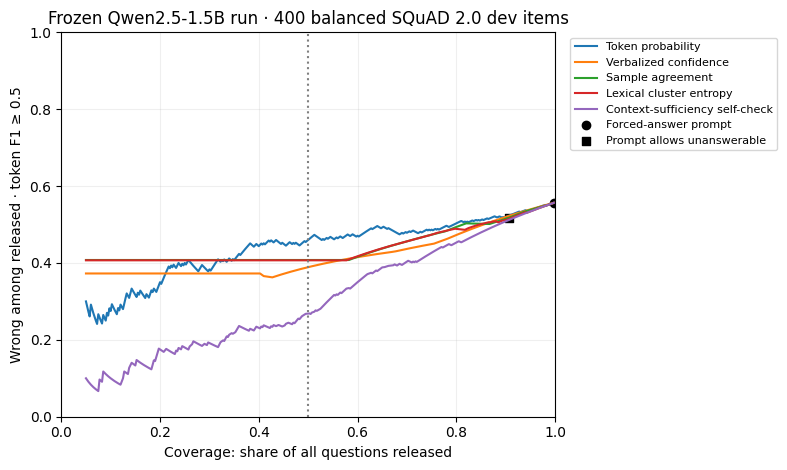

,Signal,aurc_full,aurc_from_5_percent,max_coverage,auroc
0,Token probability,0.425492,0.440833,0.9975,0.658599
1,Verbalized confidence,0.417917,0.420179,0.9975,0.720975
2,Sample agreement,0.439746,0.441347,0.9975,0.690932
3,Lexical cluster entropy,0.438708,0.440297,0.9975,0.693566
4,Context-sufficiency self-check,0.300174,0.308478,0.9975,0.855729


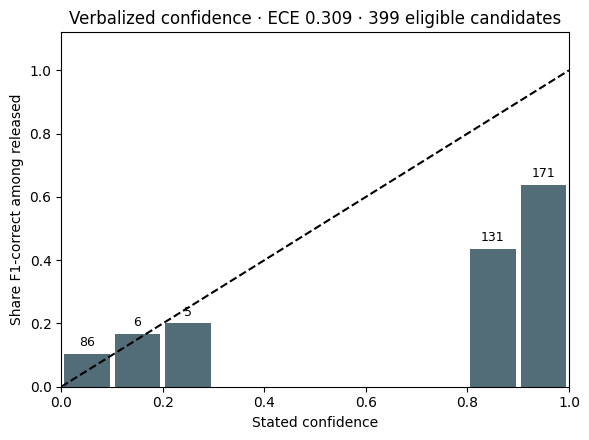

In [8]:
fig,ax=plt.subplots(figsize=(8,4.8))
for name,col in SIGNALS.items():
    cov,risk=rc_curve(DATA[col],DATA["eligible"],DATA["wrong"],400)
    ax.plot(cov[cov>=.05],risk[cov>=.05],label=name)
for name,marker in [("Forced-answer prompt","o"),("Prompt allows unanswerable","s")]:
    m=RESULT["points"][name];ax.scatter(m["coverage"],m["risk"],color="black",marker=marker,label=name)
ax.axvline(.5,color="gray",linestyle=":")
ax.set(xlabel="Coverage: share of all questions released",ylabel="Wrong among released · token F1 ≥ 0.5",xlim=(0,1),ylim=(0,1),title="Frozen Qwen2.5-1.5B run · 400 balanced SQuAD 2.0 dev items")
ax.legend(fontsize=8,bbox_to_anchor=(1.02,1),loc="upper left");ax.grid(alpha=.2);fig.tight_layout()
display(fig);plt.close(fig)
display(pd.DataFrame([{"Signal":n,**m} for n,m in RESULT["ranking"].items()]))
bins=RESULT["verbal_bins"]
fig,ax=plt.subplots(figsize=(6,4.5))
ax.bar([(b["bin"]+.5)/10 for b in bins],[b["accuracy"] for b in bins],width=.09,color="#526d78")
ax.plot([0,1],[0,1],color="black",linestyle="--")
for b in bins: ax.text((b["bin"]+.5)/10,b["accuracy"]+.025,str(b["count"]),ha="center",fontsize=9)
ax.set(xlabel="Stated confidence",ylabel="Share F1-correct among released",xlim=(0,1),ylim=(0,1.12),title=f"Verbalized confidence · ECE {RESULT['verbal_ece']:.3f} · 399 eligible candidates")
fig.tight_layout();display(fig);plt.close(fig)


## Sensitivity to scoring and grouping

The previous public notebook grouped solely by F1 ≥ 0.5, which merged examples such as `Room 204` and `Room 310`. The numeric safeguard changes agreement and entropy results; the saved model answers and SQuAD correctness rule stay unchanged. The safeguard is still a lexical heuristic, and greedy clustering is order dependent.

Exact match below changes the binary correctness definition; it is not a second model run. The prompt that allows abstention is a different-candidate baseline and should not be interpreted as a gate on the forced candidate.


In [9]:
legacy=policies(arrays([item_row(r,"public_f1") for r in SQUAD]))
display(pd.DataFrame([{"Policy":n,"Original F1-only grouping risk":pct(legacy[n]["risk"]),
                       "Numeric-guard lexical grouping risk":pct(m["risk"]),
                       "Exact-match risk":pct(RESULT["exact_match_policies"][n]["risk"])}
                      for n,m in RESULT["points"].items() if n not in ["Prompt allows unanswerable","Random eligible gate (expected 50%)"]]))


,Policy,Original F1-only grouping risk,Numeric-guard lexical grouping risk,Exact-match risk
0,Forced-answer prompt,55.64%,55.64%,62.41%
1,Token probability gate,46.00%,46.00%,51.00%
2,Verbalized confidence gate,38.91%,38.91%,46.73%
3,Sample agreement gate,41.60%,40.77%,48.93%
4,Lexical cluster entropy gate,41.53%,40.69%,48.48%
5,Context-sufficiency self-check gate,26.83%,26.83%,37.67%
6,Answerability oracle (diagnostic only),11.50%,11.50%,25.00%


## Constructed ambiguity: what clarification changes

These 12 notices were written for the tutorial. Their two readings and equal 1/2 prior were supplied by hand. The model answers both clarified questions; **the notebook does not implement or evaluate an answer/ask/decline policy**.

With one common set of lexical groups, total is entropy of pooled samples, within is mean entropy inside each reading, and between is total minus within. This is a classical mutual-information illustration inspired by input clarification ensembling, rather than a reproduction of ICE's generated clarifications. The guarded grouping makes the between-reading quantity one bit in these deliberately separable examples; that is not a general ambiguity-detection result.

Gate release probabilities use the calibration-only threshold and its tie probability consistently. A probability is not an observed release count. Applying SQuAD thresholds to these notices is a transfer illustration, not validated performance on the new domain.


In [10]:
amb_rows=[]
for a in RESULT["ambiguous"]:
    row={"id":a["id"],"Question":a["question"],"Forced answer":a["forced"],"Reading picked":a["reading_picked"],
         "Original lexical entropy (bits)":round(a["original_entropy"],3),"Total (bits)":round(a["pooled_total"],3),
         "Within (bits)":round(a["within"],3),"Between (bits)":round(a["between"],3)}
    row.update({n+" release probability":round(g["calibration_only_release_probability"],3) for n,g in a["gates"].items()})
    amb_rows.append(row)
display(pd.DataFrame(amb_rows))
print("Expected releases among 12, transferred calibration threshold:")
for n in SIGNALS: print(n,round(sum(a["gates"][n]["calibration_only_release_probability"] for a in RESULT["ambiguous"]),3))


,id,Question,Forced answer,Reading picked,Original lexical entropy (bits),Total (bits),Within (bits),Between (bits),Token probability release probability,Verbalized confidence release probability,Sample agreement release probability,Lexical cluster entropy release probability,Context-sufficiency self-check release probability
0,a01,Which room is the workshop in?,Room 204,A,0.000,1.000,0.000,1.0,1.0,0.0,0.82,0.833,1.0
1,a02,What time does the workshop start?,Friday 14:00,A,0.000,1.000,0.000,1.0,0.0,1.0,0.82,0.833,1.0
2,a03,What time does the library open?,North Library opens at 09:00,A,0.469,1.000,0.000,1.0,1.0,1.0,0.00,0.000,1.0
3,a04,Which platform does the train to Pittsburgh le...,platform 3,A,0.000,1.000,0.000,1.0,1.0,0.0,0.82,0.833,1.0
4,a05,When is the midterm?,October 14,A,1.846,1.234,0.234,1.0,1.0,0.0,0.00,0.000,0.0
5,a06,What day are office hours held?,Tuesday,A,0.469,1.000,0.000,1.0,1.0,1.0,0.00,0.000,0.0
6,a07,How often does the bus run on weekdays?,15 minutes,A,1.157,1.000,0.000,1.0,0.0,0.0,0.00,0.000,1.0
7,a08,How much does a ticket for the concert cost?,$14,B,0.000,1.000,0.000,1.0,1.0,1.0,0.82,0.833,0.0
8,a09,When is the deadline?,September 20 and December 12,both,0.881,1.000,0.000,1.0,1.0,1.0,0.00,0.000,1.0
9,a10,What time does the café close?,6 pm,A,0.000,1.000,0.000,1.0,1.0,1.0,0.82,0.833,1.0


Expected releases among 12, transferred calibration threshold:
Token probability 9.0
Verbalized confidence 7.0
Sample agreement 4.098
Lexical cluster entropy 4.167
Context-sufficiency self-check 8.0


## Density-matrix connection: a recorded exploratory check

The public notebook contains 24 recorded spectral rows from `all-mpnet-base-v2` embeddings and RBF kernels with γ = 1 and 10. **They are shown as a recorded snapshot, not recomputed from this cache:** embeddings and Gram matrices were not saved. The original means are total/within/between = .758/.160/.597 bits for γ = 1 and 1.182/.190/.991 for γ = 10; displayed values are rounded.

All answers must share a common kernel feature space. A positive-semidefinite Gram matrix K gives the mixture spectrum through K/tr(K); the two reading kernels give the within entropies. Changing γ is a kernel-sensitivity check. This shows neither a quantum computer nor an improvement in a selective-generation policy. Exact agreement with the classical hard-cluster entropy requires the corresponding matching kernel; unrelated wording alone does not guarantee equality.


In [11]:
RECORDED_SPECTRAL = [{'id': 'a01', 'gamma': 1.0, 'total': 0.489, 'within': -0.0, 'between': 0.489}, {'id': 'a01', 'gamma': 10.0, 'total': 0.994, 'within': -0.0, 'between': 0.994}, {'id': 'a02', 'gamma': 1.0, 'total': 1.103, 'within': 0.484, 'between': 0.619}, {'id': 'a02', 'gamma': 10.0, 'total': 1.581, 'within': 0.595, 'between': 0.985}, {'id': 'a03', 'gamma': 1.0, 'total': 0.638, 'within': -0.0, 'between': 0.638}, {'id': 'a03', 'gamma': 10.0, 'total': 1.0, 'within': -0.0, 'between': 1.0}, {'id': 'a04', 'gamma': 1.0, 'total': 0.606, 'within': -0.0, 'between': 0.606}, {'id': 'a04', 'gamma': 10.0, 'total': 0.999, 'within': -0.0, 'between': 0.999}, {'id': 'a05', 'gamma': 1.0, 'total': 0.827, 'within': 0.179, 'between': 0.647}, {'id': 'a05', 'gamma': 10.0, 'total': 1.2, 'within': 0.234, 'between': 0.966}, {'id': 'a06', 'gamma': 1.0, 'total': 0.56, 'within': -0.0, 'between': 0.56}, {'id': 'a06', 'gamma': 10.0, 'total': 0.998, 'within': -0.0, 'between': 0.998}, {'id': 'a07', 'gamma': 1.0, 'total': 0.99, 'within': 0.446, 'between': 0.544}, {'id': 'a07', 'gamma': 10.0, 'total': 1.472, 'within': 0.485, 'between': 0.987}, {'id': 'a08', 'gamma': 1.0, 'total': 0.95, 'within': 0.2, 'between': 0.749}, {'id': 'a08', 'gamma': 10.0, 'total': 1.234, 'within': 0.234, 'between': 1.0}, {'id': 'a09', 'gamma': 1.0, 'total': 0.708, 'within': -0.0, 'between': 0.708}, {'id': 'a09', 'gamma': 10.0, 'total': 1.0, 'within': -0.0, 'between': 1.0}, {'id': 'a10', 'gamma': 1.0, 'total': 0.408, 'within': -0.0, 'between': 0.408}, {'id': 'a10', 'gamma': 10.0, 'total': 0.979, 'within': -0.0, 'between': 0.979}, {'id': 'a11', 'gamma': 1.0, 'total': 1.361, 'within': 0.614, 'between': 0.747}, {'id': 'a11', 'gamma': 10.0, 'total': 1.734, 'within': 0.734, 'between': 1.0}, {'id': 'a12', 'gamma': 1.0, 'total': 0.45, 'within': -0.0, 'between': 0.45}, {'id': 'a12', 'gamma': 10.0, 'total': 0.989, 'within': -0.0, 'between': 0.989}]
display(pd.DataFrame(RECORDED_SPECTRAL))
print("Recorded output only. No embedding model has been loaded in this replay.")


,id,gamma,total,within,between
0,a01,1.0,0.489,-0.000,0.489
1,a01,10.0,0.994,-0.000,0.994
2,a02,1.0,1.103,0.484,0.619
3,a02,10.0,1.581,0.595,0.985
4,a03,1.0,0.638,-0.000,0.638
5,a03,10.0,1.000,-0.000,1.000
6,a04,1.0,0.606,-0.000,0.606
7,a04,10.0,0.999,-0.000,0.999
8,a05,1.0,0.827,0.179,0.647
9,a05,10.0,1.200,0.234,0.966


Recorded output only. No embedding model has been loaded in this replay.


### Assigned-matrix sanity check

These two tiny matrices reproduce the tutorial arithmetic on a CPU. They are assigned examples, not measured answer embeddings or evidence of a policy advantage. The first retains a graded overlap of 0.8; the second is the exact matching-kernel hard-group boundary with four identical samples and one separate sample.


In [12]:
def matrix_entropy(K):
    values=np.linalg.eigvalsh(K/np.trace(K))
    assert values.min()>=-1e-12
    values=values[values>1e-12]
    return float(-(values*np.log2(values)).sum())
K=np.array([[1.0,.8],[.8,1.0]])
K_groups=np.zeros((5,5));K_groups[:4,:4]=1;K_groups[4,4]=1
s_overlap=matrix_entropy(K);s_groups=matrix_entropy(K_groups);h_groups=entropy([4,1])
assert np.isclose(s_overlap,.4689955935892812)
assert np.isclose(s_groups,h_groups) and np.isclose(s_groups,.7219280948873623)
print("Assigned K/2 eigenvalues:",np.linalg.eigvalsh(K/2),"entropy:",round(s_overlap,6),"bits")
print("Matching (J4 ⊕ [1])/5 entropy:",round(s_groups,6),"bits; Shannon H(.8,.2):",round(h_groups,6),"bits")


Assigned K/2 eigenvalues: [0.1 0.9] entropy: 0.468996 bits
Matching (J4 ⊕ [1])/5 entropy: 0.721928 bits; Shannon H(.8,.2): 0.721928 bits


## Workshop answers and class activity

The table below is the model's cached output, including unsupported guesses. Class tallies are not available and are not fabricated. During the activity, keep students' answers and confidence separate from this model table.


In [13]:
ws=[]
for r in sorted((r for r in RECS if r["set"]=="workshop"),key=lambda r:r["id"]):
    ws.append({"Question":r["label"],"Gold":", ".join(r["golds"][:1]) or "not stated", "Forced reply":r["forced"],
               "Verbalized confidence":r["verbal"],"Sample agreement (lexical)":item_row(r,"number_guard")["agree"],
               "Context self-check":r["support_p_yes"],"Abstention-prompt reply":r["abstain"]})
display(pd.DataFrame(ws))


,Question,Gold,Forced reply,Verbalized confidence,Sample agreement (lexical),Context self-check,Abstention-prompt reply
0,Coding room?,204,Room 204,1.0,1.0,0.999956,Room 204
1,Design room?,310,Room 310,1.0,1.0,0.999670,Room 310
2,Coding start time?,14:00,14:00,1.0,1.0,0.999937,14:00
3,Design start time?,16:00,16:00,1.0,1.0,0.999743,16:00
4,Attendance fee?,not stated,Registration required. Bring a laptop,0.0,0.8,0.000015,unanswerable
5,Coding end time?,not stated,Friday 14:00,0.0,1.0,0.008062,Friday 14:00


### Add the class tallies after the activity

`CLASS_TALLY` starts as `None`, so no class result or class plot is generated now. After collecting the activity, enter each question's `(answered count, declined count, mean confidence among those who answered)`; confidence is from 0 to 100. Use `None` for a mean that was not collected. This comparison is an activity record, not a model benchmark.


In [14]:
CLASS_TALLY = None
# Replace None with the six actual entries after class, for example:
# CLASS_TALLY = {"Coding room?": (answered_count, declined_count, mean_confidence), ...}
# Labels: Coding room?, Design room?, Coding start time?, Design start time?, Attendance fee?, Coding end time?
if CLASS_TALLY is None:
    print("Class tallies have not been collected. No class plot is generated.")
else:
    by_label={r["label"]:r for r in RECS if r["set"]=="workshop"}
    assert set(CLASS_TALLY)==set(by_label), "Enter all six question labels."
    for label,(answered,declined,confidence) in CLASS_TALLY.items():
        assert isinstance(answered,int) and isinstance(declined,int) and answered>=0 and declined>=0
        assert confidence is None or (answered>0 and 0<=confidence<=100)
    labels=[r["Question"] for r in ws]
    class_decline=[CLASS_TALLY[l][1]/sum(CLASS_TALLY[l][:2]) if sum(CLASS_TALLY[l][:2]) else np.nan for l in labels]
    class_confidence=[CLASS_TALLY[l][2]/100 if CLASS_TALLY[l][2] is not None else np.nan for l in labels]
    model_decline=[float(is_no_answer(by_label[l]["abstain"])) for l in labels]
    model_confidence=[by_label[l]["verbal"] for l in labels]
    x=np.arange(6);fig,axes=plt.subplots(1,2,figsize=(11,4.5))
    axes[0].bar(x-.2,class_decline,.4,label="Class",color="#526d78")
    axes[0].bar(x+.2,model_decline,.4,label="Model, abstention allowed",color="#b8b1a7")
    axes[0].set_title("Share that declined")
    axes[1].bar(x-.2,class_confidence,.4,label="Class: mean among answers",color="#526d78")
    axes[1].bar(x+.2,model_confidence,.4,label="Model: forced-prompt candidate",color="#b8b1a7")
    axes[1].set_title("Stated confidence")
    for ax in axes:
        ax.set_xticks(x);ax.set_xticklabels(labels,rotation=30,ha="right",fontsize=8)
        ax.set_ylim(0,1.05);ax.legend(fontsize=8,frameon=False)
    fig.tight_layout();display(fig);plt.close(fig)


Class tallies have not been collected. No class plot is generated.


## Save the replay results

This exports the analysis and visible policy table, without changing the raw cache. An independent command-line replay is also provided as `analysis.py`. Results are conditional on one model, prompt wording, balanced sample, relaxed correctness rule, sampling budget and lexical grouping. They do not establish general deployment performance, an asking benefit, or quantum advantage.


In [15]:
EXPORT = dict(cache_sha256=CACHE_SHA256,model=META["model"],seed=SEED,
              bootstrap_resamples=BOOTSTRAP_RESAMPLES,bootstrap_unit="question",no_new_inference=True,
              corrected=RESULT,legacy_point_sensitivity=legacy)
Path("results.json").write_text(json.dumps(EXPORT,indent=2,allow_nan=False))
policy_table.to_csv("policy_table.csv",index=False)
print("Saved results.json and policy_table.csv. Raw cache unchanged.")


Saved results.json and policy_table.csv. Raw cache unchanged.


## Optional: generate a new run

The reviewed public generation functions are preserved below. They are disabled by default. A deliberate rerun needs model/dataset downloads and a suitable GPU; runtime varies. New results go to `results_cache_new.jsonl`, keeping the frozen run separate. Existing partial runs must match settings and prompt provenance before they can resume. No generation was performed while preparing this replay.


In [16]:
import re, json, string, collections, math, random, os, time

_PUNCT = set(string.punctuation)

def normalize_answer(s):
    """Official SQuAD 2.0 normalization."""
    s = s.lower()
    s = "".join(ch for ch in s if ch not in _PUNCT)
    s = re.sub(r"\b(a|an|the)\b", " ", s)
    return " ".join(s.split())

def token_f1(pred, gold):
    p, g = normalize_answer(pred).split(), normalize_answer(gold).split()
    if not p or not g:
        return float(p == g)
    same = sum((collections.Counter(p) & collections.Counter(g)).values())
    if same == 0:
        return 0.0
    prec, rec = same / len(p), same / len(g)
    return 2 * prec * rec / (prec + rec)

def best_f1(pred, golds):
    return max((token_f1(pred, g) for g in golds), default=0.0)

def exact_match(pred, golds):
    return float(any(normalize_answer(pred) == normalize_answer(g) for g in golds))

NO_ANSWER_RE = re.compile(
    r"\bunanswerable\b"
    r"|\bnot (?:mentioned|stated|specified|provided|given|included|present|found|available|known|clear)\b"
    r"|\b(?:does|do|did)\s*n[o']t (?:say|mention|specify|state|provide|contain|include|indicate|give|tell)\b"
    r"|\bno (?:information|answer|mention|data)\b"
    r"|\bcan(?:not|'t| not) be (?:determined|answered|found)\b"
    r"|^\s*(?:unknown|none|n/?a)\s*\.?\s*$",
    re.IGNORECASE)

def is_no_answer(text):
    return bool(NO_ANSWER_RE.search(text or ""))

def clean_answer(text):
    """First non-empty line, without an 'Answer:' prefix, quotes or a trailing period."""
    lines = [l.strip() for l in (text or "").strip().splitlines() if l.strip()]
    t = lines[0] if lines else ""
    t = re.sub(r"^(?:final\s+)?answer\s*[:\-]\s*", "", t, flags=re.IGNORECASE)
    t = re.sub(r"[.;,]+$", "", t.strip())
    t = t.strip("\"'“”‘’").strip()
    return re.sub(r"[.;,]+$", "", t).strip()

def parse_confidence(text):
    """First number in the reply, read as a percentage. None if there is no usable number."""
    m = re.search(r"\d+(?:\.\d+)?", text or "")
    if not m:
        return None
    v = float(m.group(0))
    if "." in m.group(0) and v <= 1.0:
        v *= 100.0            # a reply such as 0.9
    return v / 100.0 if 0.0 <= v <= 100.0 else None

PROMPTS = {
    "forced": ("Answer the question using the passage. Reply with only the answer, a short phrase taken "
               "from the passage. Always give your best answer.\n\nPassage: {context}\n\nQuestion: {question}"),
    "abstain": ("Answer the question using the passage. Reply with only the answer, a short phrase taken "
                "from the passage. If the passage does not contain the answer, reply with only the word "
                "unanswerable.\n\nPassage: {context}\n\nQuestion: {question}"),
    "verbal": ("Passage: {context}\n\nQuestion: {question}\n\nProposed answer: {answer}\n\n"
               "How likely is it that the proposed answer is correct? Reply with only a number from 0 to 100."),
    "support": ("Passage: {context}\n\nQuestion: {question}\n\n"
                "Does the passage contain the answer to this question? Reply with only Yes or No."),
}

def make_prompt(kind, context, question, answer=None):
    return PROMPTS[kind].format(context=context, question=question, answer=answer)

try:
    display
except NameError:          # outside Jupyter
    display = print

In [17]:
SQUAD_URL = "https://rajpurkar.github.io/SQuAD-explorer/dataset/dev-v2.0.json"
SQUAD_SHA256 = "80a5225e94905956a6446d296ca1093975c4d3b3260f1d6c8f68bc2ab77182d8"
SQUAD_IDS = {   # seed 597. Each half has 100 answerable and 100 unanswerable questions, in that order
    "calib": [
        "5710e8c8a58dae1900cd6b2a", "571cb010dd7acb1400e4c12a", "5725daa8ec44d21400f3d6b4", "572a0d21af94a219006aa786",
        "571097baa58dae1900cd6a9c", "57299326af94a219006aa516", "57281940ff5b5019007d9d47", "5725f8f5ec44d21400f3d7b1",
        "572fffb1b2c2fd14005686fa", "5726356938643c19005ad2ff", "5727e9523acd2414000def96", "572871bd3acd2414000dfa06",
        "572ffc99947a6a140053cef7", "57280e1aff5b5019007d9bee", "57286d4f2ca10214002da32a", "572fe393947a6a140053cdbc",
        "57265746dd62a815002e821c", "572a0b0b6aef0514001551f6", "5728f6446aef0514001548e7", "56e1ec83cd28a01900c67c0a",
        "572996c73f37b319004784b4", "5733d2dbd058e614000b633b", "5726eb4b5951b619008f826d", "5725fe63ec44d21400f3d7dd",
        "573011de04bcaa1900d770fa", "57306797396df919000960ef", "56e1c0f6cd28a01900c67b2e", "57111ab8a58dae1900cd6c3d",
        "572fc659b2c2fd1400568449", "56e1b62ecd28a01900c67aa3", "572faec7b2c2fd1400568335", "571cda1bdd7acb1400e4c197",
        "5725f7cd38643c19005acf24", "572867543acd2414000df9a3", "572985011d04691400779505", "5727d3843acd2414000ded6a",
        "570d4c3bfed7b91900d45e34", "57300580b2c2fd140056874f", "57286951ff5b5019007da20f", "571c9348dd7acb1400e4c115",
        "572861cc4b864d1900164962", "5710eca0a58dae1900cd6b3b", "57114e8d50c2381900b54a5e", "5727da564b864d1900163e8e",
        "56e1a0dccd28a01900c67a2e", "57273a465951b619008f8703", "5733d7cbd058e614000b63ab", "57263dcd89a1e219009ac5a5",
        "56dddf4066d3e219004dad5f", "572879574b864d1900164a14", "5705fd8475f01819005e7844", "5729f8516aef05140015516c",
        "57097051ed30961900e84136", "5729e2b76aef0514001550cf", "572a058aaf94a219006aa751", "5726534d708984140094c271",
        "5727e6cbff5b5019007d97ef", "57268527708984140094c8c0", "57274e975951b619008f87fa", "56e1dc62cd28a01900c67bce",
        "572885023acd2414000dfa83", "57297d421d046914007794e8", "5727490bdd62a815002e9a83", "56e1efa0e3433e140042321b",
        "5727dc473acd2414000dee45", "572ffc99947a6a140053cef6", "5726534d708984140094c270", "5730b4282461fd1900a9cfc5",
        "572686fc708984140094c8e6", "572f7b33947a6a140053c9a2", "57115f0a50c2381900b54aa7", "57108d69b654c5140001f987",
        "572677e7708984140094c723", "572667e2f1498d1400e8de92", "5727526cdd62a815002e9b10", "57286dfa2ca10214002da335",
        "5728659f4b864d190016498d", "5705e3f252bb89140068966e", "57273f27dd62a815002e9a0c", "572683f95951b619008f7529",
        "5728223cff5b5019007d9dc6", "572fdd03a23a5019007fcaa1", "5725f8f5ec44d21400f3d7b5", "5726398589a1e219009ac58a",
        "5729da0faf94a219006aa677", "57267ebfdd62a815002e872e", "57306797396df919000960f0", "5730a0778ab72b1400f9c60a",
        "572a07fc6aef0514001551df", "5728dddc2ca10214002da9d4", "57261f9f271a42140099d4aa", "573027d6a23a5019007fce9e",
        "572a1ba46aef051400155291", "57112686b654c5140001fbd6", "572982e66aef051400154f92", "57284d484b864d1900164900",
        "5725c28a271a42140099d14d", "57265f605951b619008f70dc", "5728e8212ca10214002daa6d", "57265aaf5951b619008f706c",
        "5ad23e1bd7d075001a4288b5", "5a592c9d3e1742001a15cfda", "5a66a156f038b7001ab0c072", "5ad3e83e604f3c001a3ff63c",
        "5a8933ed3b2508001a72a516", "5a668d4ef038b7001ab0bfc4", "5ad26839d7d075001a42925b", "5a550b52134fea001a0e1848",
        "5ad15a11645df0001a2d1857", "5a665338846392001a1e1ac7", "5ad4fd0f5b96ef001a10a896", "5a1c6968b4fb5d001871461b",
        "5ad55fe75b96ef001a10ad0f", "5ad3ad60604f3c001a3fec06", "5ad252e6d7d075001a428d0d", "5a8944653b2508001a72a57c",
        "5a3e488b378766001a00253e", "5ad3af11604f3c001a3fec63", "5acff3b377cf76001a6865fc", "5ad3f689604f3c001a3ff9e3",
        "5ad508665b96ef001a10aa69", "5a665549846392001a1e1ad5", "5ad4db615b96ef001a10a434", "5ad510be5b96ef001a10ab58",
        "5ad40cdb604f3c001a400092", "5ad4f3a25b96ef001a10a75c", "5ad28a57d7d075001a4299b2", "5ad0316a77cf76001a686de4",
        "5a57f0ea770dc0001aeefee5", "5ad4d55f5b96ef001a10a278", "5a25f38dc93d92001a40035b", "5ad22a96d7d075001a4285de",
        "5a0c677bf5590b0018dab3f0", "5ad21646d7d075001a4283c5", "5ad26964d7d075001a4292cc", "5a6ceb164eec6b001a80a6cb",
        "5ad25f42d7d075001a428f72", "5ad0316177cf76001a686dde", "5ad3bb12604f3c001a3feeb9", "5ad3ad60604f3c001a3fec07",
        "5ad40346604f3c001a3ffd74", "5ad40b9a604f3c001a40001b", "5a820c4931013a001a335146", "5ad3a076604f3c001a3fe9ab",
        "5ad03b7977cf76001a686ead", "5a7b12a421c2de001afe9d52", "5ad3e83e604f3c001a3ff63d", "5ad3a839604f3c001a3feaf2",
        "5ad0483977cf76001a686f8d", "5ad28ea7d7d075001a429a50", "5a2358cc82b03a001a4aa798", "5a6ce8ea4eec6b001a80a6b7",
        "5ad26235d7d075001a429080", "5ad4a049ba00c4001a268e43", "5ad4f8255b96ef001a10a810", "5ad24319d7d075001a4289d0",
        "5a580d05770dc0001aeeff98", "5ad4db9f5b96ef001a10a440", "5ad25e17d7d075001a428f16", "5ad3a27c604f3c001a3fea32",
        "5a55106f134fea001a0e18ae", "5ad3bd30604f3c001a3fef0f", "5a0c7edcf5590b0018dab43e", "5ad3c46a604f3c001a3fefb1",
        "5acfecc577cf76001a686510", "5ad25b1cd7d075001a428e67", "5ad042cf77cf76001a686f25", "5a551230134fea001a0e18cf",
        "5ad546c75b96ef001a10ac10", "5ad40b87604f3c001a400006", "5ad0312677cf76001a686dc9", "5a1c883cb4fb5d0018714670",
        "5acfa71b77cf76001a68572f", "5a82079731013a001a335120", "5a7b093b21c2de001afe9d0d", "5ad541ad5b96ef001a10abeb",
        "5a665549846392001a1e1ad9", "5ad40639604f3c001a3ffe4c", "5ad2605dd7d075001a428fc6", "5a67978ef038b7001ab0c309",
        "5ad0285977cf76001a686c0e", "5ad28614d7d075001a4298c2", "5a7b0ec521c2de001afe9d20", "5ad2424cd7d075001a42898a",
        "5ad2a71ad7d075001a429e02", "5ad2454cd7d075001a428a94", "5a637c6268151a001a922312", "5acfe73c77cf76001a6863d4",
        "5ad400f0604f3c001a3ffcf2", "5a57c667770dc0001aeefd66", "5ad265efd7d075001a4291d3", "5ad247b0d7d075001a428b46",
        "5a3e3de4378766001a002514", "5ad02bef77cf76001a686ca4", "5a57f0ea770dc0001aeefee2", "5ad28098d7d075001a4297b9",
        "5acf8d4077cf76001a6851f6", "5a66893ff038b7001ab0bf74", "5ad569c05b96ef001a10ae37", "5a81f84e31013a001a33500a"],
    "test": [
        "5729fa40af94a219006aa711", "57332c1e4776f4190066073b", "572758e0f1498d1400e8f6af", "5727f05b4b864d190016406a",
        "572684365951b619008f7540", "5727d4922ca10214002d977e", "572fbb04a23a5019007fc8f8", "572646655951b619008f6ec2",
        "57337ddc4776f41900660bbc", "572941273f37b319004781af", "5726ea985951b619008f8265", "57281ab63acd2414000df495",
        "571094b7a58dae1900cd6a68", "57265e97708984140094c3c3", "573028fa04bcaa1900d77289", "5725c0f289a1e219009abdf2",
        "572869b84b864d19001649ae", "57309ef18ab72b1400f9c601", "572849b4ff5b5019007da0f3", "5727fd123acd2414000df187",
        "57264efddd62a815002e8138", "56e1b8f3e3433e14004230e7", "572fae4b04bcaa1900d76be1", "571c91c8dd7acb1400e4c10e",
        "572885c44b864d1900164a7b", "571117d4a58dae1900cd6c0a", "5733fd66d058e614000b6735", "5727478cf1498d1400e8f59a",
        "56de16ca4396321400ee25c7", "572882242ca10214002da423", "572ff626947a6a140053ce8f", "57108198b654c5140001f93b",
        "57271f125951b619008f8639", "573003dd947a6a140053cf46", "5725b33f6a3fe71400b8952e", "57303048947a6a140053d255",
        "571117d4a58dae1900cd6c0b", "57096f37200fba1400367fe6", "5737534ec3c5551400e51eab", "5725cb33271a42140099d1db",
        "572995d46aef051400154fe8", "57287ddf3acd2414000dfa41", "57274712708984140094dbae", "572847dd4b864d19001648bd",
        "5730ac782461fd1900a9cf77", "5711619950c2381900b54aaf", "57286010ff5b5019007da1cd", "57376a1bc3c5551400e51ec4",
        "57105da9a58dae1900cd69a1", "57284b904b864d19001648e4", "5729fa40af94a219006aa70f", "571c3e8cdd7acb1400e4c0a6",
        "571cebc05efbb31900334e4b", "573009a004bcaa1900d7704f", "57340b1bd058e614000b6869", "571c3a685efbb31900334db5",
        "5730126ba23a5019007fcd0d", "573766251c45671900574473", "57273e50dd62a815002e9a02", "57113639a58dae1900cd6d1a",
        "5726415bec44d21400f3dcd4", "572a0bebaf94a219006aa772", "5737a9afc3c5551400e51f65", "572ffbaa947a6a140053cee6",
        "57106644b654c5140001f8e8", "56de1728cffd8e1900b4b5d7", "572940246aef051400154bec", "573314e3d058e614000b56f2",
        "57293d116aef051400154bcb", "5726ddf6f1498d1400e8ee08", "571c9074dd7acb1400e4c102", "57264e66dd62a815002e811b",
        "57060a1175f01819005e78d2", "5726da89dd62a815002e92b3", "572ff890a23a5019007fcbd0", "57268f2bf1498d1400e8e3c4",
        "57263ea0271a42140099d7c6", "57268d2ddd62a815002e894e", "57294209af94a219006aa201", "57308ddc396df919000961a8",
        "56e17e6ee3433e1400422f7f", "572a06af3f37b31900478668", "570d2d68fed7b91900d45cbc", "572683075951b619008f7516",
        "5725cfd0271a42140099d226", "5733140a4776f419006606e2", "573098f38ab72b1400f9c5d2", "572989846aef051400154fc4",
        "571c8eb9dd7acb1400e4c0f9", "57284b904b864d19001648e5", "572a1a5c6aef051400155284", "5733e5a14776f4190066145b",
        "57111428b654c5140001fb02", "57287c142ca10214002da3d1", "5733f5f24776f419006615c4", "570614ff52bb89140068988a",
        "5729727baf94a219006aa43b", "5726975c708984140094cb21", "5711669550c2381900b54adf", "5727500f708984140094dc01",
        "5a8203d431013a001a3350c2", "5ad25b1cd7d075001a428e66", "5ad27abcd7d075001a42962b", "5a7b402121c2de001afe9e0f",
        "5ad3ea79604f3c001a3ff6ea", "5a8373a7e60761001a2eb732", "5a23548782b03a001a4aa784", "5ad24a2ad7d075001a428bb8",
        "5ad1556e645df0001a2d17da", "5a0c6c78f5590b0018dab402", "5ad3f13e604f3c001a3ff867", "5ad02de177cf76001a686d16",
        "5a839654e60761001a2eb7f3", "5a7b34fa21c2de001afe9dc9", "5a3e539a378766001a00258b", "5ad3b3dc604f3c001a3fed67",
        "5ad0483977cf76001a686f8c", "5ad3c1ad604f3c001a3fef90", "5a38ab9fa4b263001a8c188a", "5ad254a5d7d075001a428d26",
        "5acfebe477cf76001a6864d9", "5a2c3595bfd06b001a5aea62", "5a665870846392001a1e1af3", "5a57c667770dc0001aeefd6a",
        "5ad29b43d7d075001a429bcc", "5ad3f4b1604f3c001a3ff952", "5ad4d8d65b96ef001a10a364", "5acfed0b77cf76001a686524",
        "5ad50de85b96ef001a10ab16", "5ad14816645df0001a2d1541", "5ad02e8277cf76001a686d51", "5acf9a5277cf76001a685420",
        "5a66978af038b7001ab0c02b", "5a67a1e3f038b7001ab0c389", "5ad2649ad7d075001a429161", "5a3e40d1378766001a002521",
        "5ad4f40c5b96ef001a10a775", "5a75028897ca42001a521db2", "5ad4cc135b96ef001a10a0f3", "5ad4f1365b96ef001a10a70e",
        "5ad02d3077cf76001a686cf8", "5a58cfd63e1742001a15ce33", "5ad507d25b96ef001a10aa4d", "5ad4da795b96ef001a10a3e9",
        "5ad141e1645df0001a2d1406", "5ad288e1d7d075001a429973", "5ad3ae4f604f3c001a3fec4a", "5a668d4ef038b7001ab0bfc2",
        "5acff6ea77cf76001a686682", "5ad248f7d7d075001a428b8c", "5acfe95877cf76001a686440", "5a667dae846392001a1e1c56",
        "5acfed5277cf76001a68652e", "5a1c8a1eb4fb5d0018714698", "5acf9a5277cf76001a68541c", "5ad3c57a604f3c001a3feff4",
        "5a0c6698f5590b0018dab3e5", "5ad14966645df0001a2d1582", "5a83894de60761001a2eb78d", "5a5915cd3e1742001a15cf77",
        "5a3e307f378766001a0024d8", "5acf9bcf77cf76001a68547c", "5ad0285977cf76001a686c0f", "5ad4f28c5b96ef001a10a734",
        "5ad25e99d7d075001a428f30", "5ad3f13e604f3c001a3ff865", "5ad24e50d7d075001a428c3a", "5ad3ad01604f3c001a3febd5",
        "5ad56bcd5b96ef001a10ae63", "5ad4d55f5b96ef001a10a274", "5a60556eeae51e001ab14d18", "5ad56bcd5b96ef001a10ae62",
        "5ad40158604f3c001a3ffd0d", "5ad01c8877cf76001a686a64", "5a7b33b821c2de001afe9dbf", "5a581bda770dc0001aef0002",
        "5a1c8092b4fb5d001871462e", "5a5915cd3e1742001a15cf78", "5a2eced7a83784001a7d24b3", "5ad2877cd7d075001a429915",
        "5a55068b134fea001a0e1810", "5ad3c57a604f3c001a3feff1", "5ad507d25b96ef001a10aa4c", "5ad26586d7d075001a4291b3",
        "5ad3bce5604f3c001a3feefe", "5acff4b177cf76001a686618", "5ad50bb95b96ef001a10aaaf", "5a551a65134fea001a0e191f",
        "5a83acb4e60761001a2eb862", "5a0c7fb2f5590b0018dab446", "5a38c34ea4b263001a8c190c", "5ad547945b96ef001a10ac1a",
        "5a668682f038b7001ab0bf52", "5a67b94bf038b7001ab0c444", "5ad14966645df0001a2d1583", "5ad407de604f3c001a3ffebf",
        "5ad153e9645df0001a2d1797", "5ad26278d7d075001a4290af", "5ad2647bd7d075001a42915a", "5ad2605dd7d075001a428fc9"],
}

def load_squad_items(path="dev-v2.0.json"):
    import hashlib, urllib.request
    if not os.path.exists(path): urllib.request.urlretrieve(SQUAD_URL,path)
    raw = Path(path).read_bytes()
    assert hashlib.sha256(raw).hexdigest() == SQUAD_SHA256, "SQuAD file differs from the frozen source."
    by_id={}
    for article in json.loads(raw)["data"]:
        for para in article["paragraphs"]:
            for qa in para["qas"]:
                by_id[qa["id"]]=dict(context=para["context"],question=qa["question"],title=article["title"],
                                     is_impossible=bool(qa.get("is_impossible",False)),golds=sorted({a["text"] for a in qa["answers"]}),
                                     plausible=sorted({a["text"] for a in qa.get("plausible_answers",[])}))
    items=[]
    for split in ("calib","test"):
        for qid in SQUAD_IDS[split]:items.append(dict(by_id[qid],set="squad",id=qid,split=split))
    return items


In [18]:
WORKSHOP_NOTICE = ("Coding workshop · Room 204 · Friday 14:00\n"
                   "Design workshop · Room 310 · Friday 16:00\n"
                   "Registration required. Bring a laptop.")

WORKSHOP_QUESTIONS = [   # id, worksheet label, question, gold answers, no answer in the notice
    ("w1", "Coding room?", "Which room is the coding workshop in?", ["204", "Room 204"], False),
    ("w2", "Design room?", "Which room is the design workshop in?", ["310", "Room 310"], False),
    ("w3", "Coding start time?", "What time does the coding workshop start?", ["14:00", "2 pm", "2:00 pm"], False),
    ("w4", "Design start time?", "What time does the design workshop start?", ["16:00", "4 pm", "4:00 pm"], False),
    ("w5", "Attendance fee?", "How much does it cost to attend the workshop?", [], True),
    ("w6", "Coding end time?", "What time does the coding workshop end?", [], True),
]

AMBIGUOUS = [   # id, notice, ambiguous question, (clarified question A, golds A), (clarified question B, golds B)
    ("a01", WORKSHOP_NOTICE, "Which room is the workshop in?",
     ("Which room is the coding workshop in?", ["204"]), ("Which room is the design workshop in?", ["310"])),
    ("a02", WORKSHOP_NOTICE, "What time does the workshop start?",
     ("What time does the coding workshop start?", ["14:00", "2 pm"]),
     ("What time does the design workshop start?", ["16:00", "4 pm"])),
    ("a03", "North Library opens at 09:00. South Library opens at 11:00. Both libraries close at 22:00.",
     "What time does the library open?",
     ("What time does North Library open?", ["09:00", "9:00", "9 am", "9am"]),
     ("What time does South Library open?", ["11:00", "11 am", "11am"])),
    ("a04", "The express train to Pittsburgh leaves from platform 3 at 7:15. "
            "The local train to Pittsburgh leaves from platform 5 at 7:40.",
     "Which platform does the train to Pittsburgh leave from?",
     ("Which platform does the express train to Pittsburgh leave from?", ["3"]),
     ("Which platform does the local train to Pittsburgh leave from?", ["5"])),
    ("a05", "The statistics midterm is on October 14 in Hall 1. The biology midterm is on October 16 in Hall 2.",
     "When is the midterm?",
     ("When is the statistics midterm?", ["October 14", "Oct 14"]),
     ("When is the biology midterm?", ["October 16", "Oct 16"])),
    ("a06", "Professor Lee holds office hours on Tuesday in Room 112. "
            "Professor Patel holds office hours on Thursday in Room 118.",
     "What day are office hours held?",
     ("What day does Professor Lee hold office hours?", ["Tuesday"]),
     ("What day does Professor Patel hold office hours?", ["Thursday"])),
    ("a07", "Bus 12 runs every 15 minutes on weekdays. Bus 30 runs every 40 minutes on weekdays.",
     "How often does the bus run on weekdays?",
     ("How often does Bus 12 run on weekdays?", ["15 minutes"]),
     ("How often does Bus 30 run on weekdays?", ["40 minutes"])),
    ("a08", "Student tickets for the concert cost $8. Standard tickets for the concert cost $14.",
     "How much does a ticket for the concert cost?",
     ("How much does a student ticket for the concert cost?", ["$8", "8"]),
     ("How much does a standard ticket for the concert cost?", ["$14", "14"])),
    ("a09", "The project proposal is due on September 20. The final report is due on December 12.",
     "When is the deadline?",
     ("When is the project proposal due?", ["September 20"]),
     ("When is the final report due?", ["December 12"])),
    ("a10", "The café on the first floor closes at 6 pm. The café in the library closes at 10 pm.",
     "What time does the café close?",
     ("What time does the café on the first floor close?", ["6 pm", "6pm", "18:00"]),
     ("What time does the café in the library close?", ["10 pm", "10pm", "22:00"])),
    ("a11", "Parking in Lot A costs $2 per hour. Parking in Lot B costs $5 per day.",
     "How much does parking cost?",
     ("How much does parking in Lot A cost?", ["$2 per hour", "2"]),
     ("How much does parking in Lot B cost?", ["$5 per day", "5"])),
    ("a12", "The planning meeting is in Room 4B at 10:00. The budget meeting is in Room 2A at 15:00.",
     "Where is the meeting?",
     ("Where is the planning meeting?", ["Room 4B", "4B"]),
     ("Where is the budget meeting?", ["Room 2A", "2A"])),
]

def constructed_items():
    items = []
    for qid, label, q, golds, impossible in WORKSHOP_QUESTIONS:
        items.append(dict(set="workshop", id=qid, label=label, context=WORKSHOP_NOTICE, question=q,
                          golds=golds, is_impossible=impossible, plausible=[], split=None))
    for qid, ctx, q, (qa, ga), (qb, gb) in AMBIGUOUS:
        items.append(dict(set="ambig", id=qid, context=ctx, question=q, golds=ga + gb, is_impossible=False,
                          plausible=[], split=None,
                          readings=[dict(label="A", question=qa, golds=ga), dict(label="B", question=qb, golds=gb)]))
    return items

In [19]:
def load_model():
    global torch, tok, model, DEVICE, STOP_IDS, PAD_ID, YES_ID, NO_ID, DTYPE_NAME
    import torch
    import transformers
    from transformers import AutoTokenizer, AutoModelForCausalLM
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    if DEVICE == "cpu":
        print("No GPU found. Part 1 would take hours on a CPU. "
              "Use Runtime > Change runtime type > T4 GPU, then run again.")
    cap = torch.cuda.get_device_capability() if DEVICE == "cuda" else (0, 0)
    dtype = torch.bfloat16 if cap[0] >= 8 else (torch.float16 if DEVICE == "cuda" else torch.float32)
    tok = AutoTokenizer.from_pretrained(MODEL_NAME)

    def _load(dt):
        m = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
        m = m.to(device=DEVICE, dtype=dt).eval()
        gc = m.generation_config          # neutral defaults, so nothing is applied silently
        gc.do_sample, gc.temperature, gc.top_p, gc.top_k, gc.repetition_penalty = False, 1.0, 1.0, 50, 1.0
        return m

    model = _load(dtype)
    eos = model.generation_config.eos_token_id
    STOP_IDS = set(eos if isinstance(eos, (list, tuple)) else [eos])
    for t in ("<|im_end|>", "<|endoftext|>"):
        tid = tok.convert_tokens_to_ids(t)
        if isinstance(tid, int) and tid >= 0 and tid != tok.unk_token_id:
            STOP_IDS.add(tid)
    PAD_ID = tok.pad_token_id if tok.pad_token_id is not None else min(STOP_IDS)
    YES_ID = tok.encode("Yes", add_special_tokens=False)[0]
    NO_ID = tok.encode("No", add_special_tokens=False)[0]
    DTYPE_NAME = str(dtype).replace("torch.", "")
    if not sanity_check():
        print("Output looked broken in", DTYPE_NAME, "so the model is reloading in float32.")
        model = _load(torch.float32)
        DTYPE_NAME = "float32"
        assert sanity_check(), "The model still gives broken output. Check the runtime and the model name."
    gpu = torch.cuda.get_device_name(0) if DEVICE == "cuda" else "cpu"
    print(f"Loaded {MODEL_NAME} on {gpu} in {DTYPE_NAME}. torch {torch.__version__}, "
          f"transformers {transformers.__version__}")

def chat_ids(user_text):
    text = tok.apply_chat_template([{"role": "user", "content": user_text}],
                                   tokenize=False, add_generation_prompt=True)
    return tok(text, return_tensors="pt", add_special_tokens=False).input_ids.to(DEVICE)

def _until_stop(ids):
    out = []
    for t in ids:
        if t in STOP_IDS or t == PAD_ID:
            break
        out.append(t)
    return out

def generate(ids, n=1, sample=False, max_new_tokens=MAX_NEW_TOKENS, seed=None):
    """Returns n lists of generated token ids, cut at the first stop token."""
    kw = dict(max_new_tokens=max_new_tokens, num_return_sequences=n, pad_token_id=PAD_ID,
              eos_token_id=sorted(STOP_IDS), repetition_penalty=1.0)
    if sample:
        if seed is not None:
            torch.manual_seed(seed)
        kw.update(do_sample=True, temperature=TEMPERATURE, top_p=1.0, top_k=0)   # plain sampling
    else:
        kw.update(do_sample=False)                                               # greedy
    with torch.no_grad():
        out = model.generate(input_ids=ids, attention_mask=torch.ones_like(ids), **kw)
    return [_until_stop(row[ids.shape[1]:].tolist()) for row in out]

def text_of(token_ids):
    return tok.decode(token_ids, skip_special_tokens=True)

def answer_logprob(prompt_ids, answer_ids):
    """Sum of log-probabilities of the answer tokens given the prompt (one teacher-forced pass)."""
    if len(answer_ids) == 0:
        return float("nan"), 0
    a = torch.tensor([answer_ids], device=DEVICE)
    full = torch.cat([prompt_ids, a], dim=1)
    with torch.no_grad():
        logits = model(input_ids=full).logits[0, prompt_ids.shape[1] - 1: full.shape[1] - 1].float()
    lp = torch.log_softmax(logits, dim=-1).gather(1, a[0].unsqueeze(1)).squeeze(1)
    return float(lp.sum()), len(answer_ids)

def p_yes(prompt_ids):
    """P(Yes) / (P(Yes) + P(No)) for the first reply token."""
    with torch.no_grad():
        logits = model(input_ids=prompt_ids).logits[0, -1].float()
    pair = torch.stack([logits[YES_ID], logits[NO_ID]])
    return float(torch.softmax(pair, dim=0)[0])

def sanity_check():
    reply = text_of(generate(chat_ids("What is 2 + 3? Reply with only the number."), max_new_tokens=6)[0])
    py = p_yes(chat_ids("Is snow usually white? Reply with only Yes or No."))
    ok = ("5" in reply) and math.isfinite(py) and py > 0.5
    print(f"Sanity check. 2 + 3 -> {reply!r}, P(Yes) for 'Is snow usually white?' = {py:.3f}, ok = {ok}")
    return ok

In [20]:
def run_item(context, question, seed):
    f_ids = chat_ids(make_prompt("forced", context, question))
    g = generate(f_ids)[0]
    forced_raw = text_of(g)
    forced = clean_answer(forced_raw)
    lp_sum, ntok = answer_logprob(f_ids, g)
    samples = [clean_answer(text_of(s)) for s in generate(f_ids, n=K_SAMPLES, sample=True, seed=seed)]
    v_raw = text_of(generate(chat_ids(make_prompt("verbal", context, question, forced)), max_new_tokens=8)[0])
    support = p_yes(chat_ids(make_prompt("support", context, question)))
    a_raw = text_of(generate(chat_ids(make_prompt("abstain", context, question)))[0])
    return dict(forced=forced, forced_raw=forced_raw, forced_lp_sum=lp_sum, forced_ntok=ntok,
                samples=samples, verbal_raw=v_raw.strip(), verbal=parse_confidence(v_raw),
                support_p_yes=support, abstain=clean_answer(a_raw), abstain_raw=a_raw)

def run_readings(item, seed):
    for j, rd in enumerate(item["readings"]):
        r_ids = chat_ids(make_prompt("forced", item["context"], rd["question"]))
        rd["forced"] = clean_answer(text_of(generate(r_ids)[0]))
        rd["samples"] = [clean_answer(text_of(s))
                         for s in generate(r_ids, n=K_SAMPLES, sample=True, seed=seed + 1 + j)]

def meta_record(n_items):
    import transformers
    return dict(set="meta", id="meta", model=MODEL_NAME, dtype=DTYPE_NAME,
                device=torch.cuda.get_device_name(0) if DEVICE == "cuda" else "cpu",
                torch=torch.__version__, transformers=transformers.__version__,
                k_samples=K_SAMPLES, temperature=TEMPERATURE, max_new_tokens=MAX_NEW_TOKENS, seed=SEED,
                n_items=n_items, prompts=PROMPTS,
                started_utc=time.strftime("%Y-%m-%d %H:%M:%S", time.gmtime()))

def run_generation():
    items = load_squad_items() + constructed_items()
    index = {(it["set"], it["id"]): i for i, it in enumerate(items)}
    done = set()
    if os.path.exists(CACHE_PATH):
        old_records=[json.loads(line) for line in open(CACHE_PATH) if line.strip()]
        old_meta=next((r for r in old_records if r.get("set")=="meta"),None)
        expected=dict(model=MODEL_NAME,k_samples=K_SAMPLES,temperature=TEMPERATURE,
                      max_new_tokens=MAX_NEW_TOKENS,seed=SEED,n_items=len(items),prompts=PROMPTS)
        assert old_meta and all(old_meta.get(k)==v for k,v in expected.items()), "Partial cache provenance differs. Use a new path."
        for line in open(CACHE_PATH):
            if line.strip():
                r = json.loads(line)
                done.add((r.get("set"), r.get("id")))
    todo = [it for it in items if (it["set"], it["id"]) not in done]
    print(f"{len(items)} items, {len(items) - len(todo)} already in the cache, {len(todo)} to run")
    if not todo:
        return
    load_model()
    t0 = time.time()
    with open(CACHE_PATH, "a") as f:
        if ("meta", "meta") not in done:
            f.write(json.dumps(meta_record(len(items))) + "\n")
        for i, it in enumerate(todo):
            seed = SEED * 100000 + 10 * index[(it["set"], it["id"])]
            rec = dict(it)
            rec.update(run_item(it["context"], it["question"], seed))
            if it["set"] == "ambig":
                run_readings(rec, seed)
            f.write(json.dumps(rec) + "\n")
            f.flush()
            if (i + 1) % 20 == 0 or i + 1 == len(todo):
                rate = (time.time() - t0) / (i + 1)
                print(f"{i + 1}/{len(todo)} done, {rate:.1f} s per item, "
                      f"about {rate * (len(todo) - i - 1) / 60:.0f} min left")
    print("Saved", CACHE_PATH)

if RUN_GENERATION:
    assert GENERATION_CACHE_PATH != ANALYSIS_CACHE_PATH, "Keep the frozen replay cache separate."
    CACHE_PATH = GENERATION_CACHE_PATH
    run_generation()
else:
    print("Generation disabled. Frozen outputs above were replayed without an LLM.")

Generation disabled. Frozen outputs above were replayed without an LLM.


### Optional new embedding experiment

This cell is also disabled by default, independently of generation. If explicitly enabled it downloads/loads an embedding model and computes fresh spectral values from the saved answer texts. Save its embeddings/kernel cache if exact numerical reproducibility is needed. It remains an exploratory sensitivity experiment, not a tested quantum selective policy.


In [21]:
if RUN_EMBEDDINGS:
    def vn_entropy_bits(gram):
        lam = np.linalg.eigvalsh(gram / np.trace(gram))
        lam = lam[lam > 1e-12]
        return float(-(lam * np.log2(lam)).sum())

    try:
        from sentence_transformers import SentenceTransformer
        emb_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")
        spec_rows = []
        for r in (r for r in RECS if r["set"] == "ambig"):
            sa, sb = r["readings"][0]["samples"], r["readings"][1]["samples"]
            e = emb_model.encode(sa + sb, normalize_embeddings=True)
            for gamma in (1.0, 10.0):
                sq = np.sum((e[:, None, :] - e[None, :, :]) ** 2, axis=-1)
                K = np.exp(-gamma * sq)
                na = len(sa)
                s_total = vn_entropy_bits(K)
                s_within = 0.5 * vn_entropy_bits(K[:na, :na]) + 0.5 * vn_entropy_bits(K[na:, na:])
                spec_rows.append({"id": r["id"], "gamma": gamma, "total": round(s_total, 3),
                                  "within": round(s_within, 3), "between (Holevo)": round(s_total - s_within, 3)})
        spec = pd.DataFrame(spec_rows)
        display(spec)
        print(spec.groupby("gamma")[["total", "within", "between (Holevo)"]].mean().round(3))
    except ImportError:
        print("sentence-transformers is not installed. Run  !pip install -q sentence-transformers  and rerun this cell.")
else:
    print("Embedding inference disabled; recorded snapshot only.")


Embedding inference disabled; recorded snapshot only.


## References

* Geifman, Y., & El-Yaniv, R. (2017). Selective classification for deep neural networks. Advances in Neural Information Processing Systems, 30. https://proceedings.neurips.cc/paper_files/paper/2017/file/4a8423d5e91fda00bb7e46540e2b0cf1-Paper.pdf

* Rajpurkar, P., Jia, R., & Liang, P. (2018). Know what you don’t know: Unanswerable questions for SQuAD. Proceedings of ACL, Volume 2, 784-789. doi:10.18653/v1/P18-2124. https://aclanthology.org/P18-2124/

* Xiong, M., Hu, Z., Lu, X., Li, Y., Fu, J., He, J., & Hooi, B. (2024). Can LLMs express their uncertainty? An empirical evaluation of confidence elicitation in LLMs. International Conference on Learning Representations. arXiv:2306.13063. https://arxiv.org/abs/2306.13063

* Farquhar, S., Kossen, J., Kuhn, L., & Gal, Y. (2024). Detecting hallucinations in large language models using semantic entropy. Nature, 630, 625-630. doi:10.1038/s41586-024-07421-0. https://www.nature.com/articles/s41586-024-07421-0

* Hou, B., Liu, Y., Qian, K., Andreas, J., Chang, S., & Zhang, Y. (2024). Decomposing uncertainty for large language models through input clarification ensembling. Proceedings of ICML, PMLR 235, 19023-19042. https://proceedings.mlr.press/v235/hou24b.html

* Joren, H., Zhang, J., Ferng, C.-S., Juan, D.-C., Taly, A., & Rashtchian, C. (2025). Sufficient context: A new lens on retrieval augmented generation systems. International Conference on Learning Representations. arXiv:2411.06037. https://arxiv.org/abs/2411.06037

* Nikitin, A., Kossen, J., Gal, Y., & Marttinen, P. (2024). Kernel Language Entropy: Fine-grained Uncertainty Quantification for LLMs from Semantic Similarities. Advances in Neural Information Processing Systems, 37. doi:10.52202/079017-0283. https://proceedings.neurips.cc/paper_files/paper/2024/hash/10c456d2160517581a234dfde15a7505-Abstract-Conference.html

* Walha, N., Gruber, S. G., Decker, T., Yang, Y., Javanmardi, A., Hüllermeier, E., & Buettner, F. (2026). Fine-grained uncertainty decomposition in large language models: A spectral approach. Proceedings of the AAAI Conference on Artificial Intelligence, 40(31), 26090-26098. doi:10.1609/aaai.v40i31.39811. https://ojs.aaai.org/index.php/AAAI/article/view/39811

* Yang, A., et al. (2024). Qwen2.5 Technical Report. arXiv:2412.15115. https://arxiv.org/abs/2412.15115